# 🔍 Notatbok 04 — Når forklaringer lyver

**Forklaringsverktøy er nyttige — men de kan villede deg.**

Dette er den **viktigste** notatboken i workshopen. Vi avslører fire
feller som kan få XAI-verktøy til å gi villedende eller ubrukelige svar:

| Felle | Problem |
|-------|---------|
| 1. Lekkende egenskaper | Modellen «forklarer» datalekkasje |
| 2. Korrelerte egenskaper | SHAP omfordeler kreditt uforutsigbart |
| 3. LIME-ustabilitet | Forskjellige kjøringer → forskjellige forklaringer |
| 4. Simpsons paradoks | Globale mønstre skjuler subgruppereverseringer |

## 0. Oppsett

In [22]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    %pip install -q pandas numpy scikit-learn xgboost matplotlib seaborn shap lime dice-ml ipywidgets

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import lime
import lime.lime_tabular
from sklearn.inspection import permutation_importance
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
import pickle
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
print("✅ Alle importer lastet inn.")

✅ Alle importer lastet inn.


In [24]:
load_path = "nb01_artifacts.pkl" if IN_COLAB else "../data/nb01_artifacts.pkl"
with open(load_path, "rb") as f:
    arts = pickle.load(f)
model = arts["model"]
X_train, X_test = arts["X_train"], arts["X_test"]
y_train, y_test = arts["y_train"], arts["y_test"]
feature_cols = arts["feature_cols"]
df = arts["df"]
df_model = arts["df_model"]
X, y = arts["X"], arts["y"]
print("✅ Artefakter lastet inn.")

✅ Artefakter lastet inn.


## Felle 1: Den lekkende egenskapen

`_internal_score` har vært den **viktigste egenskapen** i alle analysene
vi har gjort. Men har du sett på hvordan den forholder seg til målvariabelen?

In [25]:
print("Korrelasjon mellom _internal_score og approved:")
print(f"  {df['_internal_score'].corr(df['approved']):.3f}")
print()
# Fordeling etter godkjenningsstatus
print(df.groupby("approved")["_internal_score"].describe())

Korrelasjon mellom _internal_score og approved:
  0.609

           count       mean        std  min     25%    50%    75%    max
approved                                                                
0          806.0  28.578164  23.554915  0.0   7.525  25.95  44.75  100.0
1         4194.0  75.857773  22.503392  0.0  60.800  79.50  98.60  100.0


### Avsløringen

`_internal_score` er i bunn og grunn `approved * 80 + støy`. Den **koder
målvariabelen**. Modellen «forklarer» beslutningene sine ved å si «den interne
scoren var lav» — som er **sirkulær argumentasjon**.

Forklaringen er teknisk korrekt, men fullstendig **ubrukelig**. Dette er
**datalekkasje**, og XAI-verktøy oppdager det ikke — de forklarer gladelig
lekkasjen som om den var et meningsfullt mønster.

Klassifiseringsrapport UTEN _internal_score:
              precision    recall  f1-score   support

     Avslått       0.47      0.22      0.30       161
    Godkjent       0.86      0.95      0.91       839

    accuracy                           0.83      1000
   macro avg       0.67      0.58      0.60      1000
weighted avg       0.80      0.83      0.81      1000



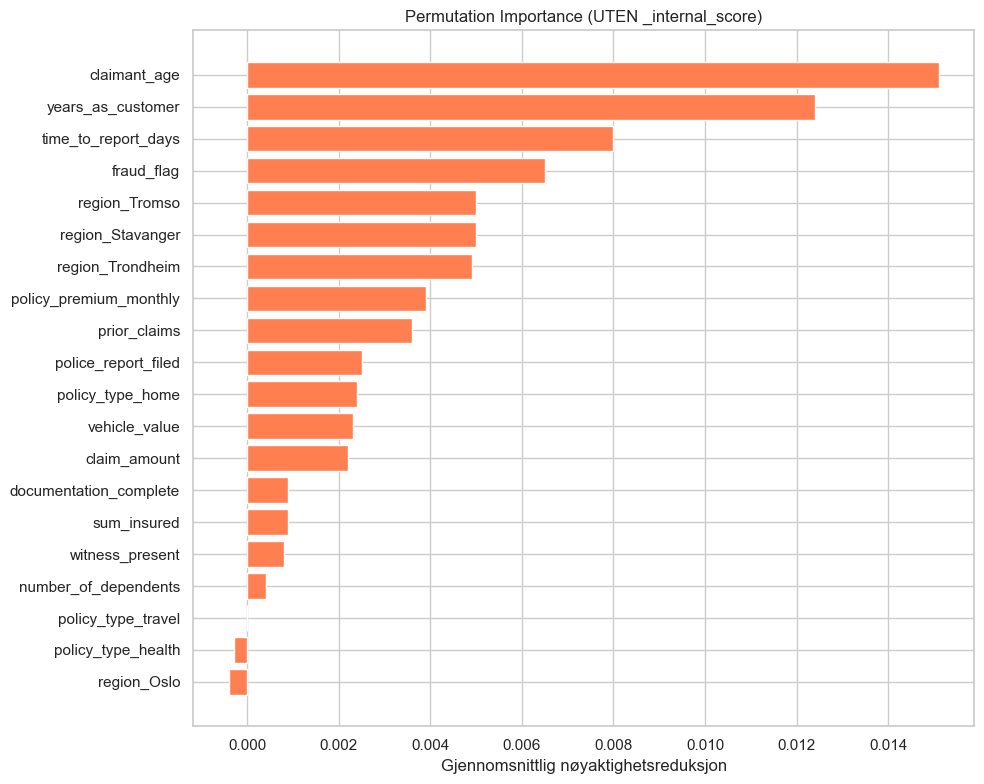

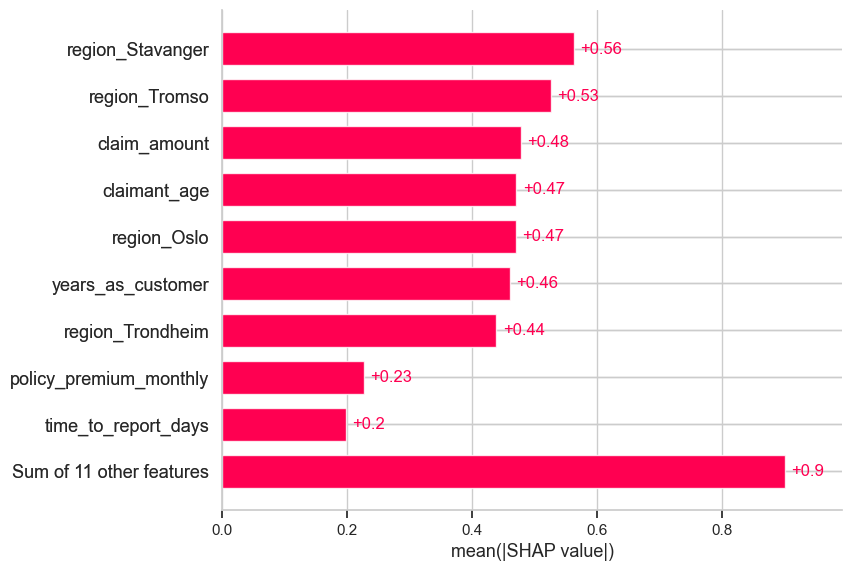


Egenskapslandskapet ser helt annerledes ut — og mer meningsfullt!


In [34]:
# Tren på nytt UTEN _internal_score
leak_free_cols = [c for c in feature_cols if c != "_internal_score"]
X_clean = X[leak_free_cols]
X_train_c, X_test_c = X_clean.loc[X_train.index], X_clean.loc[X_test.index]

model_clean = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.1,
    random_state=42, eval_metric="logloss"
)
model_clean.fit(X_train_c, y_train)
y_pred_c = model_clean.predict(X_test_c)
print("Klassifiseringsrapport UTEN _internal_score:")
print(classification_report(y_test, y_pred_c, target_names=["Avslått", "Godkjent"]))

# Ny Permutation Importance
result_c = permutation_importance(model_clean, X_test_c, y_test, n_repeats=10, random_state=42)
perm_df_c = pd.DataFrame({
    "feature": leak_free_cols,
    "importance": result_c.importances_mean
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(perm_df_c["feature"], perm_df_c["importance"], color="coral")
ax.set_xlabel("Gjennomsnittlig nøyaktighetsreduksjon")
ax.set_title("Permutation Importance (UTEN _internal_score)")
plt.tight_layout()
plt.show()

# SHAP på ren modell
explainer_c = shap.TreeExplainer(model_clean)
sv_clean = explainer_c(X_test_c)
shap.plots.bar(sv_clean)
print("\nEgenskapslandskapet ser helt annerledes ut — og mer meningsfullt!")

### Lærdommen

XAI-verktøy forklarer **modellen** trofast, men hvis modellen selv er ødelagt
(lekkende data, feil egenskaper), er forklaringen et **perfekt kart over et ødelagt
terreng**.

> Alltid revider egenskapene dine **FØR** du stoler på forklaringer.

Vi bruker den **rene modellen** (uten `_internal_score`) for resten av denne notatboken.

## Felle 2: Skallspillet med korrelerte egenskaper

`vehicle_value` og `sum_insured` er sterkt korrelerte (~0.99). Når egenskaper
er korrelerte, må SHAP fordele kreditt mellom dem — og små endringer
i dataene kan flytte attribusjon dramatisk.

Dette betyr at «viktigheten» til hver egenskap er **ustabil**.

Korrelasjon mellom vehicle_value og sum_insured:
               vehicle_value  sum_insured
vehicle_value        1.00000      0.99979
sum_insured          0.99979      1.00000


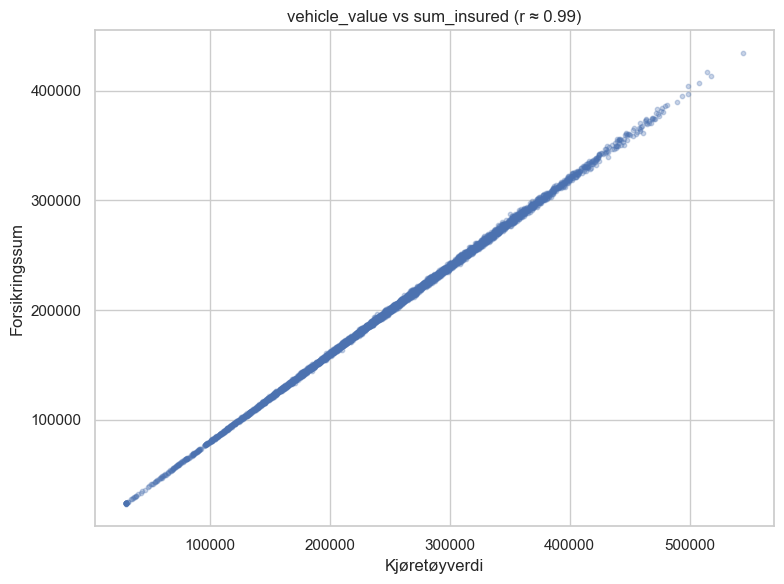

In [27]:
print("Korrelasjon mellom vehicle_value og sum_insured:")
print(df[["vehicle_value", "sum_insured"]].corr())

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df["vehicle_value"], df["sum_insured"], alpha=0.3, s=10)
ax.set_xlabel("Kjøretøyverdi")
ax.set_ylabel("Forsikringssum")
ax.set_title("vehicle_value vs sum_insured (r ≈ 0.99)")
plt.tight_layout()
plt.show()

In [32]:
# Vi bruker den rene modellen (uten _internal_score) fra Felle 1.
# For å isolere korrelasjonseffekten bruker vi en enklere modell (max_depth=1, «stumps»).
# Hvert tre bruker bare ÉN egenskap — dette gjør absorpsjonseffekten tydelig.

# ── Tren enkel modell MED begge korrelerte egenskaper ──
model_both = XGBClassifier(n_estimators=200, max_depth=2, learning_rate=0.1,
                           random_state=42, eval_metric="logloss")
model_both.fit(X_train_c, y_train)
explainer_both = shap.TreeExplainer(model_both)
sv_both = explainer_both(X_test_c)

shap_means = pd.Series(
    np.abs(sv_both.values).mean(axis=0), index=leak_free_cols
).sort_values(ascending=False)

print("SHAP gjennomsnitt |verdi| — MED begge korrelerte egenskaper:\n")
for i, (feat, val) in enumerate(shap_means.items(), 1):
    tag = "  ◄" if feat in ("vehicle_value", "sum_insured") else ""
    print(f"  {i:>2}. {feat:<28} {val:.4f}{tag}")

vv = shap_means["vehicle_value"]
si = shap_means["sum_insured"]
combined = vv + si

# ── Fjern sum_insured, tren på nytt, og sammenlign ──
cols_no_si = [c for c in leak_free_cols if c != "sum_insured"]
X_no_si = X[cols_no_si]
X_train_ns, X_test_ns = X_no_si.loc[X_train.index], X_no_si.loc[X_test.index]
model_no_si = XGBClassifier(n_estimators=300, max_depth=2, learning_rate=0.1,
                            random_state=42, eval_metric="logloss")
model_no_si.fit(X_train_ns, y_train)

explainer_ns = shap.TreeExplainer(model_no_si)
sv_no_si = explainer_ns(X_test_ns)
shap_means_ns = pd.Series(
    np.abs(sv_no_si.values).mean(axis=0), index=cols_no_si
).sort_values(ascending=False)
vv_after = shap_means_ns["vehicle_value"]

print(f"\n🎯 Absorpsjon — vehicle_value tar over:")
print(f"   MED sum_insured:   vehicle_value = {vv:.4f}  +  sum_insured = {si:.4f}  (sum = {combined:.4f})")
print(f"   UTEN sum_insured:  vehicle_value = {vv_after:.4f}")
pct = (vv_after - vv) / si * 100
print(f"\n   vehicle_value vokste med {vv_after - vv:.4f} (+{(vv_after-vv)/vv*100:.0f}%)")
print(f"   og absorberte ~{pct:.0f}% av sum_insureds opprinnelige viktighet.")

SHAP gjennomsnitt |verdi| — MED begge korrelerte egenskaper:

   1. region_Trondheim             0.5934
   2. region_Stavanger             0.5598
   3. region_Tromso                0.5578
   4. claimant_age                 0.3891
   5. years_as_customer            0.3379
   6. region_Oslo                  0.2393
   7. claim_amount                 0.2324
   8. time_to_report_days          0.1307
   9. policy_premium_monthly       0.0912
  10. fraud_flag                   0.0743
  11. documentation_complete       0.0603
  12. vehicle_value                0.0524  ◄
  13. prior_claims                 0.0418
  14. sum_insured                  0.0317  ◄
  15. witness_present              0.0244
  16. police_report_filed          0.0147
  17. number_of_dependents         0.0127
  18. policy_type_travel           0.0069
  19. policy_type_health           0.0000
  20. policy_type_home             0.0000

🎯 Absorpsjon — vehicle_value tar over:
   MED sum_insured:   vehicle_value = 0.0524  +  sum

### Lærdommen

Korrelerte egenskaper gjør forklaringer **ustabile**. Hvis du ser to korrelerte
egenskaper som deler viktighet, kan du ikke pålitelig si hvilken som «virkelig betyr noe.»

**Mulige løsninger:**
- Bruk **domenekunnskap** til å velge den mer meningsfulle egenskapen
- **Egenskapsseleksjon** for å fjerne overflødige egenskaper før trening
- **Egenskapsgruppering** (noen SHAP-implementasjoner støtter dette)

## Felle 3: LIMEs ustabilitet

LIME bruker **tilfeldige forstyrrelser** for å generere nærliggende datapunkter. Dette betyr
at kjøring flere ganger med forskjellige tilfeldige frø kan gi **forskjellige
topp-egenskaper**.

La oss teste dette på en grenseobservasjon — en sak der modellen er usikker.

In [33]:
# Finn en grenseobservasjon der modellen er usikker
probs = model_clean.predict_proba(X_test_c)[:, 1]
boundary_order = np.argsort(np.abs(probs - 0.5))
test_obs = X_test_c.index[boundary_order[0]]
test_prob = probs[boundary_order[0]]
print(f"Observasjon {test_obs}: P(godkjent) = {test_prob:.3f}")
print(f"  \u2192 N\u00e6r beslutningsgrensen \u2014 LIME b\u00f8r v\u00e6re sensitiv her.\n")

# Kj\u00f8r LIME 5 ganger med forskjellige fr\u00f8 og kun 300 forstyrrelser
lime_results = []

for seed in [0, 1, 2, 42, 99]:
    lime_exp_i = lime.lime_tabular.LimeTabularExplainer(
        X_train_c.values,
        feature_names=leak_free_cols,
        class_names=["Avsl\u00e5tt", "Godkjent"],
        mode="classification",
        random_state=seed
    )
    exp = lime_exp_i.explain_instance(
        X_clean.loc[test_obs].values,
        model_clean.predict_proba,
        num_features=10,
        num_samples=300
    )
    top3 = [item[0].split(" ")[0].replace("<=", "").replace(">", "").replace("<", "")
            for item in exp.as_list()[:3]]
    lime_results.append({"seed": seed, "top1": top3[0], "top2": top3[1], "top3": top3[2]})

lime_df = pd.DataFrame(lime_results)
print("LIME topp-3 egenskaper over 5 kj\u00f8ringer (num_samples=300):")
print(lime_df.to_string(index=False))

all_top1 = lime_df["top1"].unique()

# Sjekk konsistens
for col in ["top1", "top2", "top3"]:
    n_unique = lime_df[col].nunique()
    if n_unique > 1:
        print(f"\n\u26a0\ufe0f  {col} varierer: {list(lime_df[col].unique())}")

if len(all_top1) > 1:
    print(f"\n\u26a0\ufe0f  LIMEs topp-egenskap er IKKE stabil mellom kj\u00f8ringer!")
else:
    print(f"\nTopp-1 er stabil, men sjekk topp-2/topp-3 for ustabilitet.")

Observasjon 4703: P(godkjent) = 0.495
  → Nær beslutningsgrensen — LIME bør være sensitiv her.

LIME topp-3 egenskaper over 5 kjøringer (num_samples=300):
 seed             top1             top2             top3
    0       fraud_flag region_Stavanger    region_Tromso
    1 region_Trondheim       fraud_flag      region_Oslo
    2    region_Tromso region_Trondheim region_Stavanger
   42 region_Trondheim region_Stavanger       fraud_flag
   99    region_Tromso region_Stavanger region_Trondheim

⚠️  top1 varierer: ['fraud_flag', 'region_Trondheim', 'region_Tromso']

⚠️  top2 varierer: ['region_Stavanger', 'fraud_flag', 'region_Trondheim']

⚠️  top3 varierer: ['region_Tromso', 'region_Oslo', 'region_Stavanger', 'fraud_flag', 'region_Trondheim']

⚠️  LIMEs topp-egenskap er IKKE stabil mellom kjøringer!


### Lærdommen

LIME-forklaringer kan være **sensitive for tilfeldighet**. Hvis du presenterer en LIME-
forklaring for interessenter, **sjekk alltid stabiliteten** ved å kjøre den
flere ganger. Hvis topp-egenskapene endrer seg mellom kjøringer, er forklaringen
ikke pålitelig.

## Felle 4: Simpsons paradoks — Når gjennomsnittet lyver

Husker du ICE-plottet fra Notatbok 02 der noen linjer gikk **oppover** for
`claim_amount` mens andre gikk **nedover**? Og i Notatbok 03 — `claim_amount`
dyttet Erik mot godkjenning, men Kari mot avslag?

La oss avslàre hvorfor.

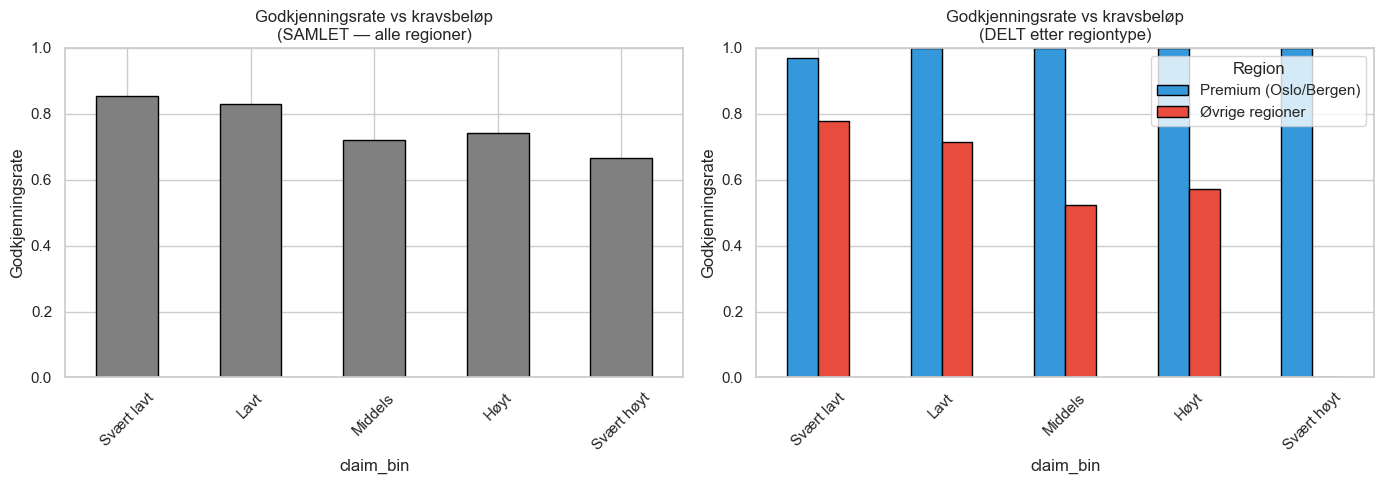

In [30]:
# Simpsons paradoks: Godkjenningsrate vs kravsbeløp, delt etter region
premium_regions = ["Oslo", "Bergen"]
df["region_type"] = df["region"].apply(
    lambda r: "Premium (Oslo/Bergen)" if r in premium_regions else "Øvrige regioner"
)
df["claim_bin"] = pd.cut(df["claim_amount"], bins=5, labels=[
    "Svært lavt", "Lavt", "Middels", "Høyt", "Svært høyt"
])

approval_by_group = df.groupby(["claim_bin", "region_type"], observed=True)["approved"].mean().unstack()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Venstre: samlet (skjuler paradokset)
overall = df.groupby("claim_bin", observed=True)["approved"].mean()
overall.plot.bar(ax=axes[0], color="gray", edgecolor="black")
axes[0].set_title("Godkjenningsrate vs kravsbeløp\n(SAMLET — alle regioner)")
axes[0].set_ylabel("Godkjenningsrate")
axes[0].set_ylim(0, 1)
axes[0].tick_params(axis='x', rotation=45)

# Høyre: delt etter regiontype (avslører paradokset)
approval_by_group.plot.bar(ax=axes[1], color=["#3498db", "#e74c3c"], edgecolor="black")
axes[1].set_title("Godkjenningsrate vs kravsbeløp\n(DELT etter regiontype)")
axes[1].set_ylabel("Godkjenningsrate")
axes[1].set_ylim(0, 1)
axes[1].legend(title="Region")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Rydd opp midlertidige kolonner
df.drop(columns=["region_type", "claim_bin"], inplace=True)

### Avsløringen

Dette er **Simpsons paradoks**: samlet sett reduserer høyere kravsbeløp
godkjenningssannsynligheten. Men når vi deler opp etter region, ser vi at
i **Oslo og Bergen** (premiumregioner) *øker* høyere beløp sjansen for
godkjenning — fordi disse regionene har premiumpoliser med bedre dekning.

**Nå gir Kari og Erik mening:**
- **Kari** (Trondheim): Høyere beløp jobber **mot** henne (ingen premiumeffekt)
- **Erik** (Oslo): Høyere beløp jobber **for** ham (premiumeffekt)

Samme egenskap, motsatt effekt — avhengig av region. PDP-plottet i Notatbok 02
viste bare **gjennomsnittet**, som skjulte denne reverseringen fullstendig.

### Lærdommen

Globale forklaringer skjuler **subgruppeeffekter**. PDP viser gjennomsnittet —
men gjennomsnittet kan lyve når grupper har **motsatte effekter**.

**Mulige løsninger:**
- Bruk **ICE-plott** i stedet for bare PDP — individuelle linjer avslører heterogenitet
- **Del opp analysen** per relevante undergrupper (region, segment, osv.)
- Bruk **SHAP-avhengighetsplott** med fargegrupper for å avdekke interaksjoner

## Øvelse 5: Tillitssjekkliste

Basert på alt du har sett, vurder hver metode.

In [31]:
# ØVELSE: Fyll inn tillitssjekklisten for hver metode
#
# Vurder hver metode (1=Lav, 2=Middels, 3=Høy) basert på det du har sett:
#
# | Metode          | Stabilitet | Trofasthet | Tolkbarhet | Samlet tillit |
# |-----------------|------------|------------|------------|---------------|
# | SHAP            |            |            |            |               |
# | LIME            |            |            |            |               |
# | PDP/ICE         |            |            |            |               |
# | DiCE            |            |            |            |               |
# | Perm. Importance|            |            |            |               |
# | Subgruppeanalyse|            |            |            |               |
#
# Merknader:
# - Stabilitet: Gir den samme svar hvis du kjører den igjen?
# - Trofasthet: Gjenspeiler den nøyaktig hva modellen gjør?
# - Tolkbarhet: Kan en ikke-teknisk interessent forstå den?

## Viktige lærdommer

> **Forklaringer forklarer MODELLEN, ikke virkeligheten.
> En trofast forklaring av en ødelagt modell er trofast ødelagt.**

Tre regler å leve etter:

1. **Sjekk alltid korrelasjoner mellom egenskaper** — korrelerte egenskaper gjør attribusjoner ustabile
2. **Revider alltid for datalekkasje** — XAI-verktøy advarer deg ikke om lekkende egenskaper
3. **Stol aldri på én enkelt forklaringsmetode** — bruk flere metoder og sammenlign
4. **Sjekk alltid for subgruppeeffekter** — globale mønstre kan skjule lokale reverseringer

👉 **Neste:** [Notatbok 05 — Skriv dommen](05_writing_the_verdict.ipynb)